## 1. Library & Data


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Data Preprocessing


In [22]:
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])


X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
y = df['Gender']
print(f"Bentuk Fitur (X): {X.shape}")
print(f"Bentuk Target (y): {y.shape}")

Bentuk Fitur (X): (200, 3)
Bentuk Target (y): (200,)


## 3. Spllit Data


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah data training: {len(X_train_scaled)}")
print(f"Jumlah data testing: {len(X_test_scaled)}")

Jumlah data training: 160
Jumlah data testing: 40


## Accuracy Test 


In [24]:
k = 8
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn.fit(X_train_scaled, y_train)


y_pred = knn.predict(X_test_scaled)
akurasi = accuracy_score(y_test, y_pred)


print(f"HASIL KLASIFIKASI KNN (EUCLIDEAN, K={k})")

print(f"Akurasi Model: {akurasi * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Female', 'Male']))

HASIL KLASIFIKASI KNN (EUCLIDEAN, K=8)
Akurasi Model: 60.00%

Classification Report:
              precision    recall  f1-score   support

      Female       0.58      0.90      0.70        21
        Male       0.71      0.26      0.38        19

    accuracy                           0.60        40
   macro avg       0.65      0.58      0.54        40
weighted avg       0.64      0.60      0.55        40



## VISUALISASI KNN (EUCLIDEAN)

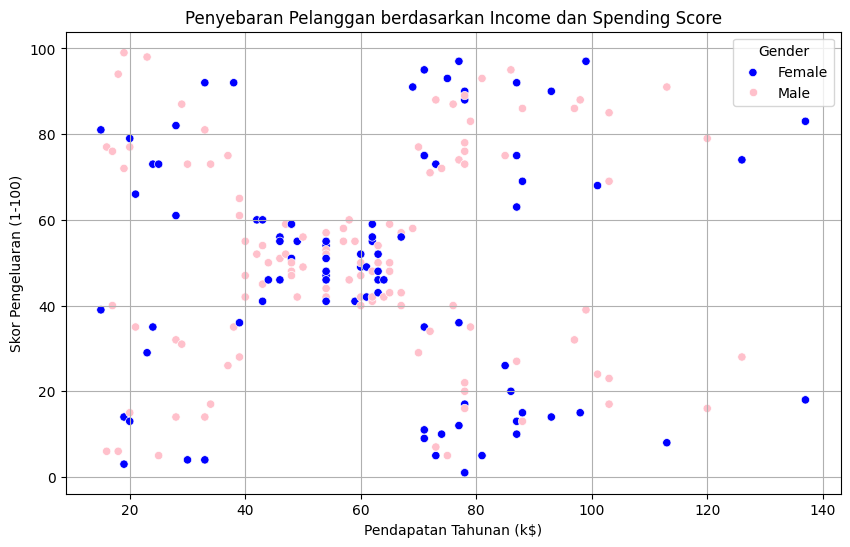

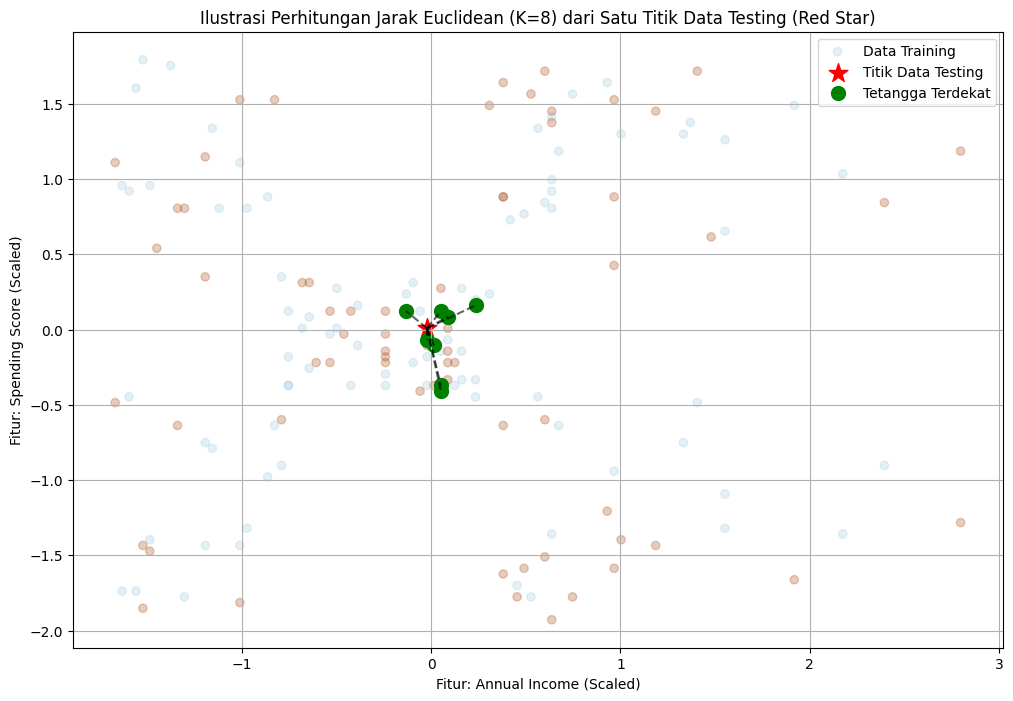


Notes:
Plot di atas menunjukkan bagaimana KNN mengklasifikasi bintang merah.
Algoritma menarik garis lurus (Euclidean distance) ke-N tetangga terdekatnya (lingkaran hijau).
Berdasarkan mayoritas label dari tetangga-tetangga hijau ini, label bintang merah akan ditentukan.


In [ ]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=df, palette={0: 'pink', 1: 'blue'})
plt.title('Penyebaran Pelanggan berdasarkan Income dan Spending Score')
plt.xlabel('Pendapatan Tahunan (k$)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.grid(True)
plt.show()

test_point_index = 0
test_point = X_test_scaled[test_point_index]
test_point_label = y_test.iloc[test_point_index]
distances, indices = knn.kneighbors([test_point])

plt.figure(figsize=(12, 8))
plt.scatter(X_train_scaled[:, 1], X_train_scaled[:, 2], c=y_train, cmap='Paired', alpha=0.3, label='Data Training')
plt.scatter(test_point[1], test_point[2], c='red', s=200, marker='*', label='Titik Data Testing')

for i in range(k):
    neighbor_index = indices[0][i]
    neighbor_point = X_train_scaled[neighbor_index]
    plt.plot([test_point[1], neighbor_point[1]], [test_point[2], neighbor_point[2]], 'k--', alpha=0.6)
    plt.scatter(neighbor_point[1], neighbor_point[2], c='green', s=100, label='Tetangga Terdekat' if i == 0 else '')

plt.title(f'Perhitungan Jarak Euclidean (K={k}) dari Satu Titik Data Testing (Red Star)')
plt.xlabel('Fitur: Annual Income (Scaled)')
plt.ylabel('Fitur: Spending Score (Scaled)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print("\nNotes:")
print("Plot di atas menunjukkan bagaimana KNN mengklasifikasi bintang merah.")
print("Algoritma menarik garis lurus (Euclidean distance) ke-N tetangga terdekatnya (lingkaran hijau).")
print("Berdasarkan mayoritas label dari tetangga-tetangga hijau ini, label bintang merah akan ditentukan.")